# 10 — Baseline Modeling Machine Learning untuk Klasifikasi Sentimen

## 1. Tujuan Tahap

Tahap ini bertujuan untuk membangun model baseline machine learning untuk klasifikasi sentimen komentar YouTube terhadap isu pelemahan nilai rupiah.

Model baseline digunakan sebagai titik awal pembanding sebelum dilakukan eksperimen model lain pada tahap berikutnya.

Pada tahap ini, pendekatan yang digunakan adalah:

1. TF-IDF sebagai metode ekstraksi fitur teks.
2. Multinomial Naive Bayes sebagai model baseline klasifikasi sentimen.
3. Train-test split untuk memisahkan data latih dan data uji.
4. Evaluasi model menggunakan accuracy, precision, recall, F1-score, classification report, dan confusion matrix.

Tahap ini tetap memperhatikan aspek keamanan data. Dataset modeling dibaca dari folder lokal `data/modeling/`, tetapi isi komentar tidak ditampilkan secara berlebihan dan file dataset tidak dipublikasikan ke GitHub.

## 2. Output yang Dihasilkan

Output yang diharapkan dari Tahap 10 adalah:

1. Dataset siap modeling berhasil dibaca dari folder `data/modeling/`.
2. Kolom fitur `text_clean` dan target `sentiment_label` berhasil divalidasi.
3. Dataset berhasil dibagi menjadi data latih dan data uji.
4. Pipeline baseline TF-IDF + Multinomial Naive Bayes berhasil dibuat.
5. Model baseline berhasil dilatih.
6. Hasil evaluasi model berhasil ditampilkan.
7. Confusion matrix berhasil divisualisasikan.
8. Laporan ringkasan evaluasi baseline berhasil disimpan ke folder `reports/`.

Catatan keamanan:

- Dataset pada folder `data/modeling/` tidak boleh dipush ke GitHub.
- Model artifact seperti file `.joblib` sebaiknya tidak dipush ke GitHub karena dapat memuat vocabulary dari data komentar.
- File yang aman untuk dipush adalah notebook dan laporan evaluasi agregat.

## 3. Konsep Baseline Modeling

Baseline modeling adalah proses membangun model awal yang sederhana untuk memperoleh gambaran performa awal dari sistem klasifikasi.

Dalam project ini, baseline modeling menggunakan pendekatan:

- **TF-IDF (Term Frequency-Inverse Document Frequency)**  
  TF-IDF digunakan untuk mengubah teks menjadi representasi numerik berdasarkan tingkat kepentingan kata dalam dokumen.

- **Multinomial Naive Bayes**  
  Multinomial Naive Bayes merupakan algoritma probabilistik yang sering digunakan untuk klasifikasi teks karena sederhana, cepat, dan cukup efektif sebagai model awal.

Model baseline ini belum dimaksudkan sebagai model final. Hasilnya akan digunakan sebagai pembanding ketika model lain seperti Logistic Regression, SVM, Random Forest, atau metode lanjutan lainnya diuji pada tahap berikutnya.

In [1]:
# ============================================================
# 10 - Baseline Sentiment Modeling
# Bagian 1: Import Library
# ============================================================

from pathlib import Path
from datetime import datetime
from IPython.display import display

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("Library berhasil di-import.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Library berhasil di-import.
Pandas version: 3.0.3
NumPy version: 2.4.6


In [2]:
# ============================================================
# Deteksi Project Root
# ============================================================
# Tujuan:
# Mendeteksi folder utama project secara otomatis.
#
# Catatan:
# Cell ini tidak membaca file .env dan tidak menampilkan API key.
# ============================================================

def find_project_root(start_path=None):
    """
    Mencari root folder project berdasarkan keberadaan folder 'data'
    dan 'notebooks'.
    """
    current_path = Path.cwd() if start_path is None else Path(start_path)
    current_path = current_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        has_data_dir = (candidate / "data").is_dir()
        has_notebooks_dir = (candidate / "notebooks").is_dir()

        if has_data_dir and has_notebooks_dir:
            return candidate

    raise FileNotFoundError(
        "Project root tidak ditemukan. Pastikan notebook berada dalam struktur project yang benar."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
MODELING_DIR = DATA_DIR / "modeling"
REPORTS_DIR = PROJECT_ROOT / "reports"

print("Project root berhasil dideteksi.")
print("Project root:", PROJECT_ROOT)
print("Folder modeling:", MODELING_DIR)
print("Folder reports:", REPORTS_DIR)

Project root berhasil dideteksi.
Project root: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis
Folder modeling: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\modeling
Folder reports: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports


In [3]:
# ============================================================
# Deteksi Dataset Modeling Terbaru
# ============================================================
# Dataset input berasal dari folder data/modeling/.
# Folder ini bersifat lokal dan tidak boleh dipublikasikan ke GitHub.
# ============================================================

SUPPORTED_EXTENSIONS = [".csv", ".xlsx", ".xls", ".parquet"]

if not MODELING_DIR.exists():
    raise FileNotFoundError(
        f"Folder data/modeling/ tidak ditemukan: {MODELING_DIR}. "
        "Pastikan Tahap 09 sudah berhasil dijalankan."
    )

modeling_files = [
    file_path
    for file_path in MODELING_DIR.iterdir()
    if file_path.is_file()
    and file_path.suffix.lower() in SUPPORTED_EXTENSIONS
    and not file_path.name.startswith("~$")
]

if len(modeling_files) == 0:
    raise FileNotFoundError(
        f"Tidak ada dataset siap modeling yang ditemukan di folder: {MODELING_DIR}"
    )

modeling_files_sorted = sorted(
    modeling_files,
    key=lambda file_path: file_path.stat().st_mtime,
    reverse=True
)

latest_modeling_file = modeling_files_sorted[0]
latest_modified_time = datetime.fromtimestamp(
    latest_modeling_file.stat().st_mtime
).strftime("%Y-%m-%d %H:%M:%S")

print("Jumlah file dataset modeling ditemukan:", len(modeling_files_sorted))
print("File dataset modeling terbaru:")
print(latest_modeling_file.name)
print("Waktu modifikasi:")
print(latest_modified_time)

file_summary = pd.DataFrame({
    "informasi": [
        "Nama file modeling terbaru",
        "Ekstensi file",
        "Waktu modifikasi",
        "Ukuran file (KB)"
    ],
    "nilai": [
        latest_modeling_file.name,
        latest_modeling_file.suffix.lower(),
        latest_modified_time,
        round(latest_modeling_file.stat().st_size / 1024, 2)
    ]
})

display(file_summary)

Jumlah file dataset modeling ditemukan: 1
File dataset modeling terbaru:
youtube_comments_modeling_ready_20260529_171713.csv
Waktu modifikasi:
2026-05-29 17:17:13


,informasi,nilai
0,Nama file modeling terbaru,youtube_comments_modeling_ready_20260529_17171...
1,Ekstensi file,.csv
2,Waktu modifikasi,2026-05-29 17:17:13
3,Ukuran file (KB),419.58


In [4]:
# ============================================================
# Load Dataset Modeling Secara Aman
# ============================================================
# Catatan keamanan:
# - Tidak membaca file .env.
# - Tidak menampilkan API key.
# - Tidak menampilkan kolom author.
# - Tidak menampilkan komentar mentah secara penuh.
# ============================================================

def load_dataset_safely(file_path):
    """
    Membaca dataset berdasarkan ekstensi file.
    """
    file_extension = file_path.suffix.lower()

    if file_extension == ".csv":
        try:
            return pd.read_csv(file_path)
        except UnicodeDecodeError:
            return pd.read_csv(file_path, encoding="utf-8-sig")

    elif file_extension in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    elif file_extension == ".parquet":
        return pd.read_parquet(file_path)

    else:
        raise ValueError(f"Format file tidak didukung: {file_extension}")


df_modeling = load_dataset_safely(latest_modeling_file)

print("Dataset modeling berhasil dibaca.")
print("Nama file:", latest_modeling_file.name)
print("Jumlah baris:", df_modeling.shape[0])
print("Jumlah kolom:", df_modeling.shape[1])

Dataset modeling berhasil dibaca.
Nama file: youtube_comments_modeling_ready_20260529_171713.csv
Jumlah baris: 3661
Jumlah kolom: 2


In [5]:
# ============================================================
# Validasi Kolom Fitur dan Target
# ============================================================

FEATURE_COLUMN = "text_clean"
TARGET_COLUMN = "sentiment_label"

required_columns = [FEATURE_COLUMN, TARGET_COLUMN]
missing_columns = [col for col in required_columns if col not in df_modeling.columns]

validation_result = pd.DataFrame({
    "kolom_wajib": required_columns,
    "status": [
        "Tersedia" if col in df_modeling.columns else "Tidak tersedia"
        for col in required_columns
    ]
})

display(validation_result)

if missing_columns:
    raise KeyError(f"Kolom wajib tidak ditemukan: {missing_columns}")

expected_labels = {"positif", "negatif", "netral"}

df_modeling[FEATURE_COLUMN] = df_modeling[FEATURE_COLUMN].astype("string").str.strip()
df_modeling[TARGET_COLUMN] = df_modeling[TARGET_COLUMN].astype("string").str.strip().str.lower()

df_modeling = df_modeling.dropna(subset=[FEATURE_COLUMN, TARGET_COLUMN]).copy()

invalid_labels = sorted(list(set(df_modeling[TARGET_COLUMN].unique()) - expected_labels))

if invalid_labels:
    raise ValueError(f"Ditemukan label tidak valid: {invalid_labels}")

print("Validasi kolom fitur dan target berhasil.")
print("Jumlah data setelah validasi:", df_modeling.shape[0])

,kolom_wajib,status
0,text_clean,Tersedia
1,sentiment_label,Tersedia


Validasi kolom fitur dan target berhasil.
Jumlah data setelah validasi: 3661


,sentiment_label,jumlah,persentase
0,netral,2416,65.99
1,negatif,637,17.4
2,positif,608,16.61


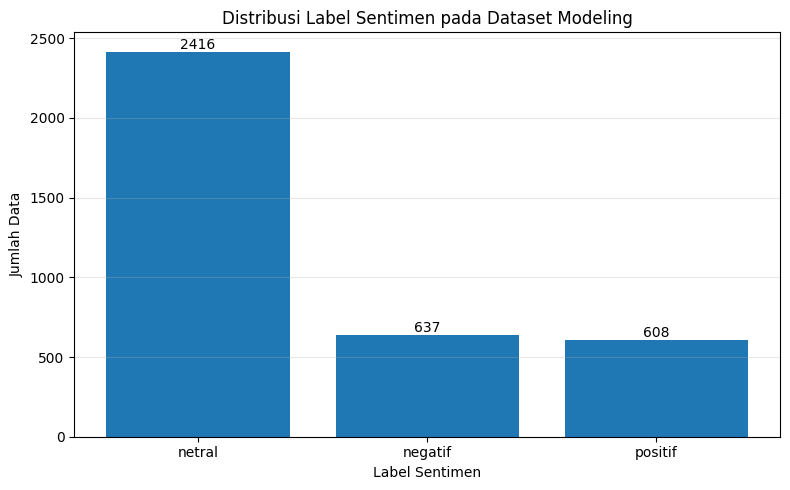

In [6]:
# ============================================================
# Pemeriksaan Distribusi Target
# ============================================================

target_distribution = (
    df_modeling[TARGET_COLUMN]
    .value_counts()
    .rename_axis("sentiment_label")
    .reset_index(name="jumlah")
)

target_distribution["persentase"] = (
    target_distribution["jumlah"] / target_distribution["jumlah"].sum() * 100
).round(2)

display(target_distribution)

plt.figure(figsize=(8, 5))
plt.bar(
    target_distribution["sentiment_label"],
    target_distribution["jumlah"]
)

plt.title("Distribusi Label Sentimen pada Dataset Modeling")
plt.xlabel("Label Sentimen")
plt.ylabel("Jumlah Data")
plt.grid(axis="y", alpha=0.3)

for index, row in target_distribution.iterrows():
    plt.text(
        index,
        row["jumlah"],
        str(row["jumlah"]),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 4. Pembagian Data Latih dan Data Uji

Dataset dibagi menjadi data latih dan data uji.

- Data latih digunakan untuk melatih model.
- Data uji digunakan untuk mengukur kemampuan model terhadap data yang belum pernah dilihat sebelumnya.

Pada tahap ini digunakan proporsi:

- 80% data latih
- 20% data uji

Pembagian dilakukan menggunakan parameter `stratify` agar distribusi label pada data latih dan data uji tetap proporsional.

In [7]:
# ============================================================
# Train-Test Split
# ============================================================

X = df_modeling[FEATURE_COLUMN]
y = df_modeling[TARGET_COLUMN]

label_counts = y.value_counts()
min_label_count = label_counts.min()

if min_label_count < 2:
    print("Peringatan: Ada label dengan jumlah data kurang dari 2.")
    print("Stratify tidak digunakan karena jumlah data pada salah satu kelas terlalu kecil.")
    stratify_option = None
else:
    stratify_option = y

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_option
)

split_summary = pd.DataFrame({
    "dataset": ["Data latih", "Data uji", "Total"],
    "jumlah_data": [len(X_train), len(X_test), len(X_train) + len(X_test)],
    "persentase": [
        round(len(X_train) / len(X) * 100, 2),
        round(len(X_test) / len(X) * 100, 2),
        100.00
    ]
})

display(split_summary)

print("Train-test split berhasil.")

,dataset,jumlah_data,persentase
0,Data latih,2928,79.98
1,Data uji,733,20.02
2,Total,3661,100.00


Train-test split berhasil.


In [8]:
# ============================================================
# Distribusi Label pada Data Latih dan Data Uji
# ============================================================

train_distribution = y_train.value_counts().rename_axis("label").reset_index(name="train_count")
test_distribution = y_test.value_counts().rename_axis("label").reset_index(name="test_count")

split_distribution = pd.merge(
    train_distribution,
    test_distribution,
    on="label",
    how="outer"
).fillna(0)

split_distribution["train_count"] = split_distribution["train_count"].astype(int)
split_distribution["test_count"] = split_distribution["test_count"].astype(int)

display(split_distribution)

print("Distribusi label pada data latih dan data uji berhasil diperiksa.")

,label,train_count,test_count
0,negatif,510,127
1,netral,1932,484
2,positif,486,122


Distribusi label pada data latih dan data uji berhasil diperiksa.


## 5. Baseline Model: TF-IDF + Multinomial Naive Bayes

Pada tahap ini dibuat model baseline menggunakan pipeline yang terdiri dari:

1. `TfidfVectorizer` untuk mengubah teks menjadi fitur numerik.
2. `MultinomialNB` sebagai algoritma klasifikasi.

Model ini dipilih karena sederhana, cepat, dan umum digunakan untuk klasifikasi teks. Hasil dari model baseline ini akan menjadi acuan awal sebelum dilakukan eksperimen model lain.

In [9]:
# ============================================================
# Training Baseline Model
# ============================================================
# Model baseline:
# - TF-IDF
# - Multinomial Naive Bayes
# ============================================================

baseline_model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("model", MultinomialNB())
])

baseline_model.fit(X_train, y_train)

print("Training baseline model selesai.")
print("Model yang digunakan: TF-IDF + Multinomial Naive Bayes")

Training baseline model selesai.
Model yang digunakan: TF-IDF + Multinomial Naive Bayes


In [10]:
# ============================================================
# Prediksi Data Uji
# ============================================================

y_pred = baseline_model.predict(X_test)

print("Prediksi data uji selesai.")
print("Jumlah data uji:", len(y_test))
print("Jumlah prediksi:", len(y_pred))

Prediksi data uji selesai.
Jumlah data uji: 733
Jumlah prediksi: 733


In [11]:
# ============================================================
# Evaluasi Metrik Utama
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

evaluation_summary = pd.DataFrame({
    "metrik": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1-Score Macro",
        "Precision Weighted",
        "Recall Weighted",
        "F1-Score Weighted"
    ],
    "nilai": [
        round(accuracy, 4),
        round(precision_macro, 4),
        round(recall_macro, 4),
        round(f1_macro, 4),
        round(precision_weighted, 4),
        round(recall_weighted, 4),
        round(f1_weighted, 4)
    ]
})

display(evaluation_summary)

,metrik,nilai
0,Accuracy,0.6780
1,Precision Macro,0.8576
2,Recall Macro,0.3699
3,F1-Score Macro,0.3379
4,Precision Weighted,0.7666
5,Recall Weighted,0.6780
6,F1-Score Weighted,0.5665


In [12]:
# ============================================================
# Classification Report
# ============================================================

report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report_dict).transpose()
classification_report_df = classification_report_df.round(4)

display(classification_report_df)

,precision,recall,f1-score,support
negatif,0.9000,0.0709,0.1314,127.000
netral,0.6727,0.9979,0.8037,484.000
positif,1.0000,0.0410,0.0787,122.000
accuracy,0.6780,0.6780,0.6780,0.678
macro avg,0.8576,0.3699,0.3379,733.000
weighted avg,0.7666,0.6780,0.5665,733.000


,Predicted negatif,Predicted netral,Predicted positif
Actual negatif,9,118,0
Actual netral,1,483,0
Actual positif,0,117,5


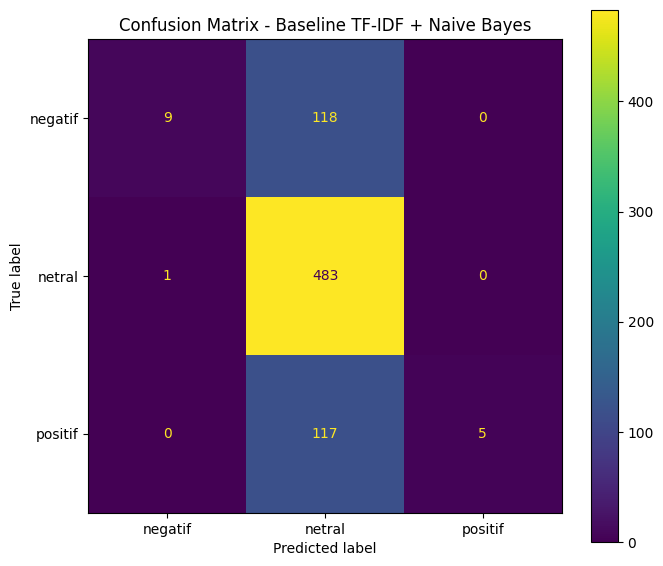

In [13]:
# ============================================================
# Confusion Matrix
# ============================================================

labels_order = ["negatif", "netral", "positif"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_order
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels_order],
    columns=[f"Predicted {label}" for label in labels_order]
)

display(cm_df)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_order
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Baseline TF-IDF + Naive Bayes")
plt.tight_layout()
plt.show()

## 6. Interpretasi Awal Model Baseline

Hasil evaluasi baseline model perlu dibaca secara hati-hati.

Accuracy menunjukkan tingkat prediksi benar secara keseluruhan. Namun, karena distribusi label sebelumnya cenderung tidak seimbang, accuracy saja tidak cukup untuk menilai kualitas model.

Metrik yang lebih penting untuk diperhatikan adalah:

1. **Precision**, untuk melihat ketepatan prediksi pada masing-masing label.
2. **Recall**, untuk melihat kemampuan model menemukan data pada setiap kelas sentimen.
3. **F1-score**, untuk melihat keseimbangan antara precision dan recall.
4. **Confusion matrix**, untuk melihat pola kesalahan prediksi antar kelas.

Jika F1-score pada label minoritas rendah, maka model kemungkinan masih lebih mudah mengenali kelas dominan dibandingkan kelas minoritas.

In [14]:
# ============================================================
# Simpan Laporan Evaluasi Baseline
# ============================================================
# Laporan ini aman karena hanya memuat metrik agregat,
# bukan isi komentar.
# ============================================================

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

report_filename = f"report_10_baseline_sentiment_modeling_{timestamp}.md"
report_path = REPORTS_DIR / report_filename

evaluation_summary_markdown = evaluation_summary.to_markdown(index=False)
classification_report_markdown = classification_report_df.reset_index().rename(
    columns={"index": "label"}
).to_markdown(index=False)
confusion_matrix_markdown = cm_df.to_markdown()

report_content = f"""# Report 10 - Baseline Sentiment Modeling

## 1. Ringkasan Tahap

Tahap ini membangun model baseline untuk klasifikasi sentimen komentar YouTube terhadap isu pelemahan nilai rupiah.

Model baseline yang digunakan:

- Feature extraction: TF-IDF
- Model: Multinomial Naive Bayes

## 2. Dataset

- File input lokal: `{latest_modeling_file.name}`
- Folder input: `data/modeling/`
- Jumlah data total: `{len(X)}`
- Jumlah data latih: `{len(X_train)}`
- Jumlah data uji: `{len(X_test)}`

## 3. Evaluasi Metrik Utama

{evaluation_summary_markdown}

## 4. Classification Report

{classification_report_markdown}

## 5. Confusion Matrix

{confusion_matrix_markdown}

## 6. Catatan Keamanan

- File `.env` tidak dibaca.
- API key tidak ditampilkan.
- Kolom `author` tidak digunakan.
- Isi komentar tidak ditampilkan dalam laporan.
- Dataset pada folder `data/modeling/` tidak boleh dipublikasikan ke GitHub.

## 7. Kesimpulan Awal

Model baseline TF-IDF + Multinomial Naive Bayes telah berhasil dilatih dan dievaluasi.

Hasil evaluasi ini menjadi acuan awal untuk membandingkan model lain pada tahap berikutnya.
"""

with open(report_path, "w", encoding="utf-8") as file:
    file.write(report_content)

print("Laporan evaluasi baseline berhasil disimpan.")
print("Nama file:", report_filename)
print("Lokasi:", report_path)

Laporan evaluasi baseline berhasil disimpan.
Nama file: report_10_baseline_sentiment_modeling_20260529_172628.md
Lokasi: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\report_10_baseline_sentiment_modeling_20260529_172628.md


## 7. Kesimpulan Tahap 10

Tahap 10 telah menghasilkan model baseline untuk klasifikasi sentimen menggunakan pendekatan TF-IDF dan Multinomial Naive Bayes.

Hasil utama dari tahap ini adalah:

1. Dataset siap modeling berhasil dibaca dari folder `data/modeling/`.
2. Data berhasil dibagi menjadi data latih dan data uji.
3. Model baseline berhasil dilatih.
4. Evaluasi model berhasil dilakukan menggunakan accuracy, precision, recall, F1-score, classification report, dan confusion matrix.
5. Laporan evaluasi baseline berhasil disimpan ke folder `reports/`.

Tahap berikutnya adalah melakukan analisis hasil baseline dan menentukan apakah perlu dilakukan eksperimen model pembanding, seperti Logistic Regression atau Linear SVM.

## 8. Analisis Perilaku Model Baseline

Berdasarkan hasil evaluasi, model baseline TF-IDF + Multinomial Naive Bayes menghasilkan accuracy sebesar 0.6780. Namun, nilai accuracy ini belum dapat dijadikan indikator utama karena distribusi label sentimen tidak seimbang.

Hasil classification report menunjukkan bahwa kelas `netral` memiliki recall sangat tinggi, yaitu 0.9979. Hal ini berarti hampir seluruh komentar netral berhasil dikenali oleh model.

Sebaliknya, kelas `negatif` dan `positif` memiliki recall yang sangat rendah. Recall kelas `negatif` hanya sebesar 0.0709, sedangkan recall kelas `positif` hanya sebesar 0.0410. Artinya, sebagian besar komentar negatif dan positif justru diklasifikasikan sebagai netral.

Confusion matrix juga memperkuat temuan ini. Dari 127 komentar negatif pada data uji, hanya 9 komentar yang berhasil diprediksi sebagai negatif, sedangkan 118 komentar diprediksi sebagai netral. Dari 122 komentar positif, hanya 5 komentar yang berhasil diprediksi sebagai positif, sedangkan 117 komentar diprediksi sebagai netral.

Dengan demikian, model baseline ini cenderung bias terhadap kelas mayoritas, yaitu `netral`. Model ini dapat digunakan sebagai pembanding awal, tetapi belum layak digunakan sebagai model final.

In [15]:
# ============================================================
# Analisis Distribusi Prediksi Model
# ============================================================
# Tujuan:
# Melihat kecenderungan prediksi model terhadap masing-masing label.
# ============================================================

actual_distribution = (
    pd.Series(y_test, name="actual_label")
    .value_counts()
    .rename_axis("label")
    .reset_index(name="jumlah_actual")
)

predicted_distribution = (
    pd.Series(y_pred, name="predicted_label")
    .value_counts()
    .rename_axis("label")
    .reset_index(name="jumlah_predicted")
)

prediction_comparison = pd.merge(
    actual_distribution,
    predicted_distribution,
    on="label",
    how="outer"
).fillna(0)

prediction_comparison["jumlah_actual"] = prediction_comparison["jumlah_actual"].astype(int)
prediction_comparison["jumlah_predicted"] = prediction_comparison["jumlah_predicted"].astype(int)

prediction_comparison["selisih_prediksi"] = (
    prediction_comparison["jumlah_predicted"] - prediction_comparison["jumlah_actual"]
)

display(prediction_comparison)

print("Analisis distribusi prediksi selesai.")

,label,jumlah_actual,jumlah_predicted,selisih_prediksi
0,negatif,127,10,-117
1,netral,484,718,234
2,positif,122,5,-117


Analisis distribusi prediksi selesai.


In [16]:
# ============================================================
# Ringkasan Diagnostik Baseline
# ============================================================
# Tujuan:
# Membuat ringkasan akademik dari perilaku model baseline.
# ============================================================

diagnostic_summary = pd.DataFrame({
    "aspek": [
        "Accuracy",
        "F1-Score Macro",
        "F1-Score Weighted",
        "Kelas dengan recall tertinggi",
        "Kelas dengan recall terendah",
        "Masalah utama model",
        "Status model baseline"
    ],
    "hasil": [
        round(accuracy, 4),
        round(f1_macro, 4),
        round(f1_weighted, 4),
        "netral",
        "positif",
        "Model terlalu dominan memprediksi kelas netral",
        "Valid sebagai baseline, tetapi belum layak sebagai model final"
    ]
})

display(diagnostic_summary)

,aspek,hasil
0,Accuracy,0.678
1,F1-Score Macro,0.3379
2,F1-Score Weighted,0.5665
3,Kelas dengan recall tertinggi,netral
4,Kelas dengan recall terendah,positif
5,Masalah utama model,Model terlalu dominan memprediksi kelas netral
6,Status model baseline,"Valid sebagai baseline, tetapi belum layak seb..."


## 9. Kesimpulan Evaluasi Baseline

Model baseline TF-IDF + Multinomial Naive Bayes telah berhasil dibangun dan dievaluasi.

Berdasarkan hasil evaluasi, model memperoleh accuracy sebesar 0.6780. Namun, nilai F1-score macro hanya sebesar 0.3379. Hal ini menunjukkan bahwa performa model antar kelas masih belum seimbang.

Model sangat baik dalam mengenali kelas `netral`, tetapi lemah dalam mengenali kelas `negatif` dan `positif`. Kondisi ini terlihat dari rendahnya recall pada kelas negatif dan positif.

Dengan demikian, model baseline ini belum dapat digunakan sebagai model final. Model ini akan digunakan sebagai pembanding awal untuk tahap berikutnya.

Tahap berikutnya perlu difokuskan pada:

1. penggunaan model pembanding,
2. penanganan ketidakseimbangan kelas,
3. evaluasi metrik yang lebih adil seperti macro F1-score,
4. analisis kesalahan prediksi antar kelas.

In [17]:
# ============================================================
# Simpan Report Evaluasi Baseline dengan Interpretasi
# ============================================================
# Laporan ini aman karena hanya berisi metrik agregat,
# bukan isi komentar.
# ============================================================

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

report_filename = f"report_10_baseline_sentiment_modeling_interpretation_{timestamp}.md"
report_path = REPORTS_DIR / report_filename

evaluation_summary_markdown = evaluation_summary.to_markdown(index=False)

classification_report_markdown = classification_report_df.reset_index().rename(
    columns={"index": "label"}
).to_markdown(index=False)

confusion_matrix_markdown = cm_df.to_markdown()

prediction_comparison_markdown = prediction_comparison.to_markdown(index=False)
diagnostic_summary_markdown = diagnostic_summary.to_markdown(index=False)

report_content = f"""# Report 10 - Baseline Sentiment Modeling with Interpretation

## 1. Ringkasan Tahap

Tahap ini membangun model baseline untuk klasifikasi sentimen komentar YouTube terhadap isu pelemahan nilai rupiah.

Model baseline yang digunakan:

- Feature extraction: TF-IDF
- Model: Multinomial Naive Bayes

## 2. Dataset

- File input lokal: `{latest_modeling_file.name}`
- Folder input: `data/modeling/`
- Jumlah data total: `{len(X)}`
- Jumlah data latih: `{len(X_train)}`
- Jumlah data uji: `{len(X_test)}`

## 3. Evaluasi Metrik Utama

{evaluation_summary_markdown}

## 4. Classification Report

{classification_report_markdown}

## 5. Confusion Matrix

{confusion_matrix_markdown}

## 6. Distribusi Aktual dan Prediksi

{prediction_comparison_markdown}

## 7. Ringkasan Diagnostik

{diagnostic_summary_markdown}

## 8. Interpretasi Akademik

Model baseline TF-IDF + Multinomial Naive Bayes memperoleh accuracy sebesar {accuracy:.4f}. Secara sekilas, nilai accuracy ini terlihat cukup baik. Namun, karena dataset memiliki distribusi label yang tidak seimbang, accuracy tidak dapat dijadikan satu-satunya indikator kualitas model.

Nilai F1-score macro sebesar {f1_macro:.4f} menunjukkan bahwa performa model antar kelas masih rendah. Model sangat dominan mengenali kelas netral, tetapi lemah dalam mengenali kelas negatif dan positif.

Berdasarkan confusion matrix, sebagian besar komentar negatif dan positif diprediksi sebagai netral. Hal ini menunjukkan bahwa model cenderung bias terhadap kelas mayoritas.

Dengan demikian, model baseline ini valid sebagai pembanding awal, tetapi belum layak digunakan sebagai model final.

## 9. Rekomendasi Tahap Berikutnya

Tahap berikutnya perlu difokuskan pada:

1. membangun model pembanding,
2. menggunakan pendekatan penanganan imbalance class,
3. mengevaluasi model menggunakan macro F1-score,
4. membandingkan performa model baseline dengan model baru.

## 10. Catatan Keamanan

- File `.env` tidak dibaca.
- API key tidak ditampilkan.
- Kolom `author` tidak digunakan.
- Isi komentar tidak ditampilkan dalam laporan.
- Dataset pada folder `data/modeling/` tidak boleh dipublikasikan ke GitHub.
"""

with open(report_path, "w", encoding="utf-8") as file:
    file.write(report_content)

print("Report evaluasi baseline dengan interpretasi berhasil disimpan.")
print("Nama file:", report_filename)
print("Lokasi:", report_path)

Report evaluasi baseline dengan interpretasi berhasil disimpan.
Nama file: report_10_baseline_sentiment_modeling_interpretation_20260529_173009.md
Lokasi: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\report_10_baseline_sentiment_modeling_interpretation_20260529_173009.md
